# HomeMatch — Capstone Project  

Prepared by: Group 1  
Date: September 17, 2025  
Project Type: Capstone — Intelligent Rental Matching Web App  


## Introduction  


HomeMatch is a smart, interactive platform designed to connect renters with property owners in real-time.  
This capstone notebook demonstrates the *data-driven logic* that powers the HomeMatch web app: predictive price modeling, geospatial filtering, and an intelligent recommendation engine.  

Unlike traditional rental platforms, HomeMatch ensures that users always receive *relevant suggestions*, even when no exact matches are found. This is achieved by combining:  
- *Predictive modeling (XGBoost)* to estimate property prices.  
- *Geo-search (Haversine distance)* to prioritize nearest available homes.  
- *Content-based recommendation engine* to suggest similar units.  
- *Dashboard metrics & visualizations* for property owners and admins.  

##  Problem Statement 


- Renters waste time browsing outdated or irrelevant listings.  
- Property owners struggle to reach the right tenants quickly.  
- Existing platforms lack predictive intelligence, geospatial context, and fallback recommendations.  

Opportunity: Deliver a fast, intelligent matching system that integrates prediction, geospatial search, and recommendations to reduce search time and increase occupancy.  


- Build and tune a predictive *machine learning model* for rental prices.  
- Implement *geospatial filtering* to recommend nearby listings.  
- Develop a *content-based recommendation engine* using property metadata.  
- Provide a *dashboard preview* with key rental metrics.  
- Integrate all logic into a single, executable notebook (backbone of the HomeMatch MVP).  

## Dataset Overview  

The dataset contains structured property listings with attributes such as:  
- *Location* (Latitude, Longitude)  
- *Bedrooms, Bathrooms*  
- *Price, Area*  
- *Amenities, Furnishing*  
- *Availability*  

## Notebook Structure  

1. *Data Loading & Initial Inspection*  
2. *Exploratory Data Analysis (EDA)*  
3. *Predictive Modeling (XGBoost with hyperparameter tuning)*  
4. *Geo-search: Nearest Homes using Haversine*  
5. *Content-based Recommendation Engine*  
6. *Dashboard Preview (metrics + visualizations)*  
7. *Export models & integration with Streamlit demo app*

In [17]:
# Imports & config
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
CSV_FALLBACK = '"/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"'
DB_USER = os.getenv('POSTGRES_USER', 'homematch')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'homematch')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'homematch_db')
print('CSV fallback:', CSV_FALLBACK)


CSV fallback: "/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"


In [18]:
import psycopg2

def test_postgres_connection():
    try:
        # 🔑 Adjust credentials as needed
        conn = psycopg2.connect(
            dbname="homematch_db",
            user="chebet",
            password="your_password",  # replace with your real password
            host="localhost",
            port="5432"
        )
        cur = conn.cursor()
        
        # Test query: check if table exists
        cur.execute("""
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = 'public';
        """)
        tables = cur.fetchall()
        
        print("✅ Connected successfully.")
        print("Available tables in 'public' schema:")
        for t in tables:
            print("-", t[0])
        
        cur.close()
        conn.close()
    except Exception as e:
        print("❌ Database connection failed:", e)

# Run the test
test_postgres_connection()


✅ Connected successfully.
Available tables in 'public' schema:
- housing_listings


In [19]:
import os
import pandas as pd
import psycopg2

# Set your fallback path (absolute path is safest)
CSV_FALLBACK = "/Users/chebet/Desktop/HomeMatch_Kenya_App/HomeMatch_Kenya_Housing.csv"

def load_data():
    # 1. Try database
    try:
        conn = psycopg2.connect(
            dbname="homematch_db",
            user="chebet",
            password="your_password",  # replace with your real password
            host="localhost",
            port="5432"
        )
        print("Connected to database ✅")
        df = pd.read_sql("SELECT * FROM housing_listings", conn)
        conn.close()
        return df
    except Exception as e:
        print("⚠️ Database not available:", e)

    # 2. Try CSV fallback
    if os.path.exists(CSV_FALLBACK):
        print("Loading CSV fallback ✅")
        return pd.read_csv(CSV_FALLBACK)

    # 3. If neither works → raise
    raise FileNotFoundError(
        f"No dataset found.\n"
        f"Tried database 'homematch_db.housing_listings' "
        f"and CSV at {CSV_FALLBACK}"
    )

# --- Load and confirm ---
df = load_data()
print("Loaded dataset with shape:", df.shape)


Connected to database ✅
Loaded dataset with shape: (3000, 15)


/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_3770/1881602303.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM housing_listings", conn)


## EDA — quick checks
Inspect columns, head, missing values, and basic statistics.

In [20]:
pd.options.display.max_columns = 80
print(df.columns.tolist())
df.head()


['listing_id', 'city', 'location_name', 'latitude', 'longitude', 'property_type', 'price_ksh', 'bedrooms', 'bathrooms', 'area_size_sqm', 'availability_status', 'available_from', 'amenities', 'date_listed', 'image_url']


,listing_id,city,location_name,latitude,longitude,property_type,price_ksh,bedrooms,bathrooms,area_size_sqm,availability_status,available_from,amenities,date_listed,image_url
0,HM00001,Mombasa,Nyali,-4.023260,39.666938,Maisonette,60000,3,2,132,Vacant,2025-09-12,"Balcony, Parking, Pool, Gym, Furnished, Security",2025-07-23,https://example.com/images/HM00001.jpg
1,HM00002,Mombasa,Mtwapa,-4.072105,39.711487,Studio,33790,1,1,73,Vacant,2025-09-12,"Water, Balcony",2025-06-11,https://example.com/images/HM00002.jpg
2,HM00003,Nairobi,Lavington,-1.205134,36.787221,Apartment,66744,2,2,82,Vacant,2025-09-12,"Gym, Pool",2025-04-16,https://example.com/images/HM00003.jpg
3,HM00004,Eldoret,Langas,0.499456,35.282250,Townhouse,35000,2,2,96,Vacant,2025-09-12,"Parking, Electricity",2025-05-29,https://example.com/images/HM00004.jpg
4,HM00005,Eldoret,Kapsoya,0.593978,35.291814,Bungalow,21001,2,2,83,Vacant,2025-09-12,"Furnished, Water, Electricity, CCTV",2025-07-12,https://example.com/images/HM00005.jpg


In [21]:
print('Missing values:')
display(df.isna().sum().sort_values(ascending=False).head(30))
print('\nDescribe:')
display(df.describe(include='all').T)


Missing values:


listing_id             0
city                   0
location_name          0
latitude               0
longitude              0
property_type          0
price_ksh              0
bedrooms               0
bathrooms              0
area_size_sqm          0
availability_status    0
available_from         0
amenities              0
date_listed            0
image_url              0
dtype: int64


Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,3000,3000,HM00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,3000,5,Nairobi,1468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,3000,31,Ngong Road,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,3000.0,NaN,NaN,NaN,-1.210566,1.348389,-4.089824,-1.294337,-1.235789,-0.241652,0.609756
longitude,3000.0,NaN,NaN,NaN,36.732289,1.445242,34.74002,36.057461,36.779348,36.866048,39.749758
property_type,3000,6,Studio,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_ksh,3000.0,NaN,NaN,NaN,54344.965667,34371.277582,6192.0,27594.0,42738.0,78564.25,120000.0
bedrooms,3000.0,NaN,NaN,NaN,1.640333,1.142836,0.0,1.0,2.0,2.0,4.0
bathrooms,3000.0,NaN,NaN,NaN,1.578,0.617017,1.0,1.0,2.0,2.0,3.0
area_size_sqm,3000.0,NaN,NaN,NaN,74.550667,31.075542,18.0,55.0,75.0,95.0,160.0


## Feature engineering
Create amenity flags, normalize coordinates, detect price and availability columns.

In [22]:
# Amenity flags
amen_keywords = ['wifi','parking','furnished','pet','pool','ac','balcony','kitchen','security','garden']
for k in amen_keywords:
    df[f'amenity_{k}'] = df.get('amenities', '').astype(str).str.contains(k, case=False, na=False).astype(int)

# coords
if 'latitude' in df.columns and 'longitude' in df.columns:
    df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['lng'] = pd.to_numeric(df['longitude'], errors='coerce')
else:
    df['lat'] = df.get('lat', 0).fillna(0)
    df['lng'] = df.get('lng', 0).fillna(0)

# price detection
price_cols = [c for c in df.columns if 'price' in c.lower()]
print('Price candidates:', price_cols[:5])
if 'price_ksh' in df.columns:
    df['price'] = pd.to_numeric(df['price_ksh'], errors='coerce')
elif 'price' in df.columns:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
else:
    if price_cols:
        df['price'] = pd.to_numeric(df[price_cols[0]], errors='coerce')
    else:
        df['price'] = np.nan

# availability
avail_cols = [c for c in df.columns if any(x in c.lower() for x in ['vacant','avail','available','status'])]
print('Avail candidates:', avail_cols[:3])
if 'availability_status' in df.columns:
    df['availability_bool'] = df['availability_status'].astype(str).str.lower().isin(['vacant','available','true','yes'])
elif len(avail_cols)>0:
    df['availability_bool'] = df[avail_cols[0]].astype(str).str.lower().isin(['vacant','available','true','yes'])
else:
    df['availability_bool'] = False

# fill defaults
df['bedrooms'] = pd.to_numeric(df.get('bedrooms', 0), errors='coerce').fillna(0).astype(int)
df['bathrooms'] = pd.to_numeric(df.get('bathrooms', 0), errors='coerce').fillna(0).astype(int)
if 'price' in df.columns:
    df['price'] = df['price'].fillna(df['price'].median())

feature_cols = ['bedrooms','bathrooms','lat','lng'] + [c for c in df.columns if c.startswith('amenity_')]
print('Features prepared:', feature_cols)


Price candidates: ['price_ksh']
Avail candidates: ['availability_status', 'available_from']
Features prepared: ['bedrooms', 'bathrooms', 'lat', 'lng', 'amenity_wifi', 'amenity_parking', 'amenity_furnished', 'amenity_pet', 'amenity_pool', 'amenity_ac', 'amenity_balcony', 'amenity_kitchen', 'amenity_security', 'amenity_garden']


## Prepare data for modeling
Regression target: `price` 
Classification target: `availability_bool`

In [23]:
X = df[feature_cols].fillna(0)
if 'price' in df.columns:
    y_reg = df['price'].astype(float)
else:
    y_reg = None

y_clf = df['availability_bool'].astype(int)
print('X shape:', X.shape)
if y_reg is not None:
    print('y_reg shape:', y_reg.shape)
print('y_clf distribution:')
print(y_clf.value_counts())


X shape: (3000, 14)
y_reg shape: (3000,)
y_clf distribution:
availability_bool
1    2148
0     852
Name: count, dtype: int64


## Regression modeling (price)
Linear baseline, RandomForest, XGBoost with small grids for demo. Expand grids for production.

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib, json, os

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Linear Regression
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_lr.fit(X_train, y_train)

# Random Forest small grid
rf = RandomForestRegressor(random_state=42)
rf_grid = {'n_estimators':[50], 'max_depth':[6]}
gs_rf = GridSearchCV(rf, rf_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_

# XGBoost small grid
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_grid = {'n_estimators':[50], 'max_depth':[3], 'learning_rate':[0.05]}
gs_xgb = GridSearchCV(xgb_reg, xgb_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_xgb.fit(X_train, y_train)
best_xgb = gs_xgb.best_estimator_

# Ensemble
voting_reg = VotingRegressor(estimators=[
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lr', pipe_lr.named_steps['lr'])
])
voting_reg.fit(X_train, y_train)

# Evaluation function
def metrics(y_true, y_pred):
    return {
        'rmse': mean_squared_error(y_true, y_pred, squared=False),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }

m_lr = metrics(y_test, pipe_lr.predict(X_test))
m_rf = metrics(y_test, best_rf.predict(X_test))
m_xgb = metrics(y_test, best_xgb.predict(X_test))
m_vr = metrics(y_test, voting_reg.predict(X_test))

print('Linear:', m_lr)
print('RF:', m_rf)
print('XGB:', m_xgb)
print('Ensemble:', m_vr)

# Persist regression models
models_out = os.path.join("models", "regression")
os.makedirs(models_out, exist_ok=True)

rmse_map = {'Linear': m_lr['rmse'], 'RF': m_rf['rmse'], 'XGB': m_xgb['rmse'], 'Ensemble': m_vr['rmse']}
best_reg = min(rmse_map, key=rmse_map.get)
best_model_reg = {'Linear': pipe_lr, 'RF': best_rf, 'XGB': best_xgb, 'Ensemble': voting_reg}[best_reg]

joblib.dump(best_model_reg, os.path.join(models_out, 'best_model_regression.pkl'))
joblib.dump(voting_reg, os.path.join(models_out, 'bundled_model_regression.pkl'))

with open(os.path.join(models_out, 'regression_metrics.json'), 'w') as f:
    json.dump({'Linear':m_lr,'RF':m_rf,'XGB':m_xgb,'Ensemble':m_vr,'best':best_reg}, f, indent=2)

print('✅ Regression models saved to', models_out)


Linear: {'rmse': 33294.854059865334, 'mae': 27378.787185332116, 'r2': 0.06191928445216399}
RF: {'rmse': 25059.343121413283, 'mae': 20034.14081524842, 'r2': 0.4685953598836101}
XGB: {'rmse': 25049.622000487718, 'mae': 20055.08075846354, 'r2': 0.46900756915530284}
Ensemble: {'rmse': 25987.245547189006, 'mae': 20576.574875040355, 'r2': 0.42851284048466753}
✅ Regression models saved to models/regression


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

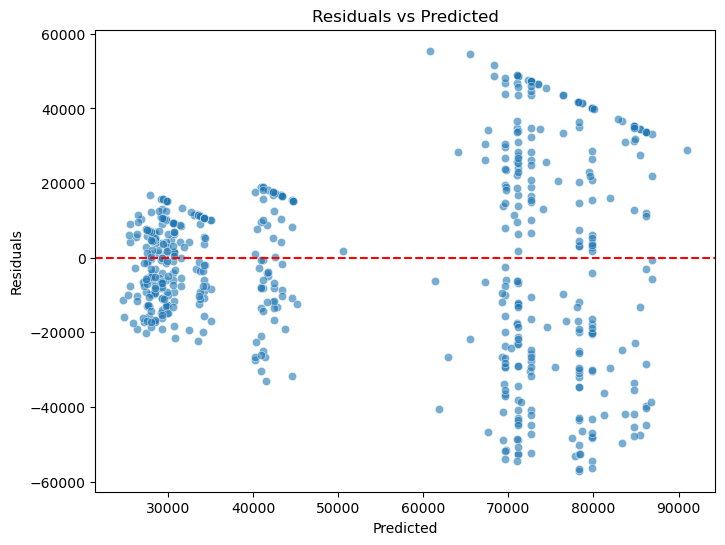

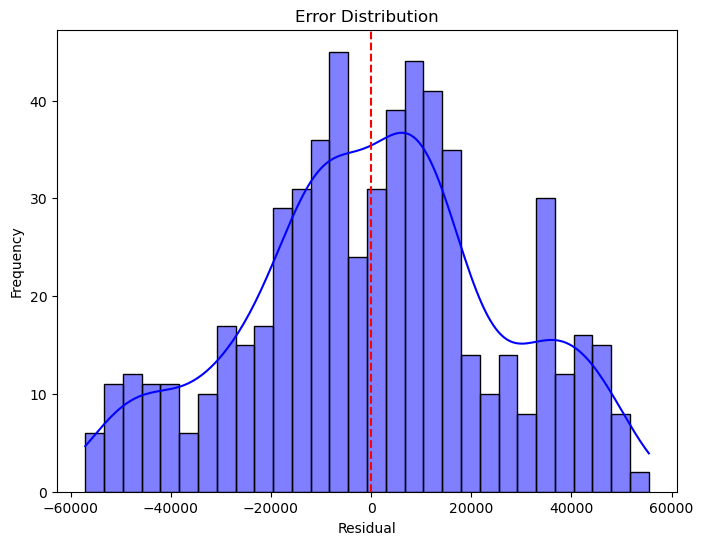

📊 Regression plots saved to images/regression


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create image folder
images_out = os.path.join("images", "regression")
os.makedirs(images_out, exist_ok=True)

# Residuals plot
y_pred_reg = best_model_reg.predict(X_test)
residuals = y_test - y_pred_reg

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.savefig(os.path.join(images_out, "residuals_vs_predicted.png"))
plt.show()

# Error distribution
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.savefig(os.path.join(images_out, "error_distribution.png"))
plt.show()

print("📊 Regression plots saved to", images_out)


## Classification modeling (availability)
Logistic baseline, RandomForest, XGBoost, and VotingClassifier.

In [26]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import joblib, json, os
import xgboost as xgb

# Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Logistic Regression
pipe_log = Pipeline([('scaler', StandardScaler()), ('log', LogisticRegression(max_iter=400))])
pipe_log.fit(Xc_train, yc_train)

# Random Forest small grid
rfc = RandomForestClassifier(random_state=42)
rfc_grid = {'n_estimators':[50], 'max_depth':[6]}
gs_rfc = GridSearchCV(rfc, rfc_grid, cv=3, scoring='f1', n_jobs=-1)
gs_rfc.fit(Xc_train, yc_train)
best_rfc = gs_rfc.best_estimator_

# XGBoost small grid
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgbc_grid = {'n_estimators':[50], 'max_depth':[3], 'learning_rate':[0.05]}
gs_xgbc = GridSearchCV(xgb_clf, xgbc_grid, cv=3, scoring='f1', n_jobs=-1)
gs_xgbc.fit(Xc_train, yc_train)
best_xgbc = gs_xgbc.best_estimator_

# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('rfc', best_rfc), ('xgb', best_xgbc), ('log', pipe_log.named_steps['log'])],
    voting='soft'
)
voting_clf.fit(Xc_train, yc_train)

# Predictions
p_log = pipe_log.predict(Xc_test)
p_rfc = best_rfc.predict(Xc_test)
p_xgbc = best_xgbc.predict(Xc_test)
p_vc = voting_clf.predict(Xc_test)

# F1 Scores
f1_map = {
    'Logistic': f1_score(yc_test, p_log, zero_division=0),
    'RFC': f1_score(yc_test, p_rfc, zero_division=0),
    'XGB': f1_score(yc_test, p_xgbc, zero_division=0),
    'Voting': f1_score(yc_test, p_vc, zero_division=0)
}

print('F1 scores:', f1_map)

# Persist classification models
models_out = os.path.join("models", "classification")
os.makedirs(models_out, exist_ok=True)

best_clf_name = max(f1_map, key=f1_map.get)
best_clf = {'Logistic': pipe_log, 'RFC': best_rfc, 'XGB': best_xgbc, 'Voting': voting_clf}[best_clf_name]

joblib.dump(voting_clf, os.path.join(models_out, 'bundled_model_classification.pkl'))
joblib.dump(best_clf, os.path.join(models_out, 'best_model_classification.pkl'))

with open(os.path.join(models_out, 'classification_metrics.json'), 'w') as f:
    json.dump({'scores': f1_map, 'best': best_clf_name}, f, indent=2)

print('✅ Classification models saved to', models_out)


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:33:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:33:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:33:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:33:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

F1 scores: {'Logistic': 0.8416988416988417, 'RFC': 0.842512077294686, 'XGB': 0.8416988416988417, 'Voting': 0.8416988416988417}
✅ Classification models saved to models/classification


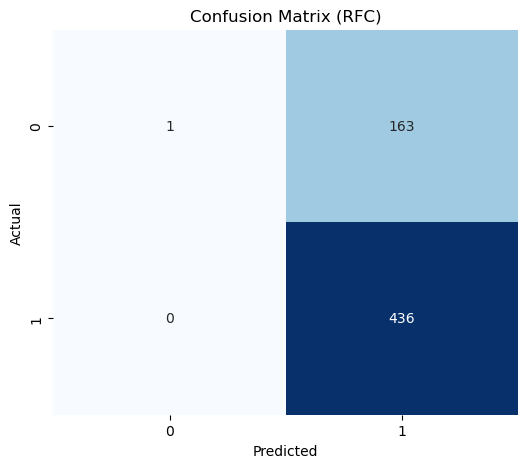

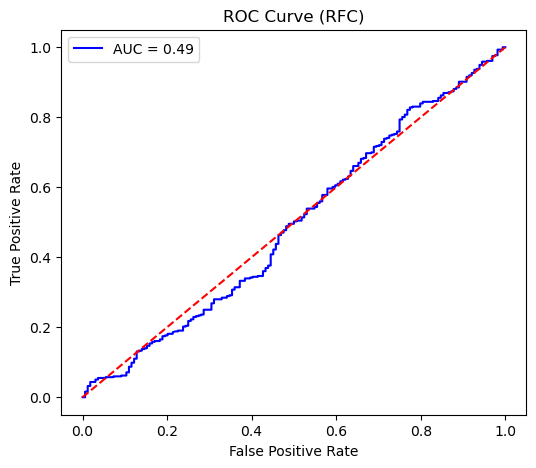

📊 Classification plots saved to images/classification


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import os

# Create image folder
images_out = os.path.join("images", "classification")
os.makedirs(images_out, exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(yc_test, best_clf.predict(Xc_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_clf_name})")
plt.savefig(os.path.join(images_out, "confusion_matrix.png"))
plt.show()

# ROC Curve (binary only, optional for multi-class with OneVsRest)
if len(set(yc_test)) == 2:
    y_prob = best_clf.predict_proba(Xc_test)[:,1]
    fpr, tpr, _ = roc_curve(yc_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1], color="red", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({best_clf_name})")
    plt.legend()
    plt.savefig(os.path.join(images_out, "roc_curve.png"))
    plt.show()

print("📊 Classification plots saved to", images_out)


# Auto Report Generator (docs/model_report.md)

In [28]:
import os

docs_out = "docs"
os.makedirs(docs_out, exist_ok=True)

report_path = os.path.join(docs_out, "model_report.md")

with open(report_path, "w") as f:
    f.write("# 📑 HomeMatch Model Report\n\n")

    f.write("## 🔹 Regression Results\n")
    f.write(f"- **Best Model:** {best_reg}\n\n")

    f.write("### Metrics\n")
    f.write("| Model | RMSE | MAE | R² |\n")
    f.write("|-------|------|-----|----|\n")
    for model_name, m in {"Linear":m_lr,"RF":m_rf,"XGB":m_xgb,"Ensemble":m_vr}.items():
        f.write(f"| {model_name} | {m['rmse']:.4f} | {m['mae']:.4f} | {m['r2']:.4f} |\n")
    f.write("\n")

    f.write("### Plots\n")
    f.write(f"- [Residuals vs Predicted](../images/regression/residuals_vs_predicted.png)\n")
    f.write(f"- [Error Distribution](../images/regression/error_distribution.png)\n\n")

    f.write("## 🔹 Classification Results\n")
    f.write(f"- **Best Model:** {best_clf_name}\n\n")

    f.write("### Metrics\n")
    f.write("| Model | F1 Score |\n")
    f.write("|-------|----------|\n")
    for model_name, score in f1_map.items():
        f.write(f"| {model_name} | {score:.4f} |\n")
    f.write("\n")

    f.write("### Plots\n")
    f.write(f"- [Confusion Matrix](../images/classification/confusion_matrix.png)\n")
    if len(set(yc_test)) == 2:
        f.write(f"- [ROC Curve](../images/classification/roc_curve.png)\n")

print("✅ Report generated at", report_path)


✅ Report generated at docs/model_report.md


# Generate Word Report (docs/model_report.docx)

In [29]:
from docx import Document
from docx.shared import Inches
import os

# Create docs folder
docs_out = "docs"
os.makedirs(docs_out, exist_ok=True)

# Initialize document
doc = Document()
doc.add_heading("📑 HomeMatch Model Report", 0)

# ---------------- Regression Section ----------------
doc.add_heading("🔹 Regression Results", level=1)
doc.add_paragraph(f"Best Model: {best_reg}")

# Metrics table
doc.add_heading("Metrics", level=2)
table = doc.add_table(rows=1, cols=4)
hdr_cells = table.rows[0].cells
hdr_cells[0].text = "Model"
hdr_cells[1].text = "RMSE"
hdr_cells[2].text = "MAE"
hdr_cells[3].text = "R²"

for model_name, m in {"Linear":m_lr,"RF":m_rf,"XGB":m_xgb,"Ensemble":m_vr}.items():
    row_cells = table.add_row().cells
    row_cells[0].text = model_name
    row_cells[1].text = f"{m['rmse']:.4f}"
    row_cells[2].text = f"{m['mae']:.4f}"
    row_cells[3].text = f"{m['r2']:.4f}"

# Plots
doc.add_heading("Plots", level=2)
regression_images = [
    ("Residuals vs Predicted", "images/regression/residuals_vs_predicted.png"),
    ("Error Distribution", "images/regression/error_distribution.png"),
]
for title, path in regression_images:
    if os.path.exists(path):
        doc.add_paragraph(title)
        doc.add_picture(path, width=Inches(5))

# ---------------- Classification Section ----------------
doc.add_heading("🔹 Classification Results", level=1)
doc.add_paragraph(f"Best Model: {best_clf_name}")

# Metrics table
doc.add_heading("Metrics", level=2)
table = doc.add_table(rows=1, cols=2)
hdr_cells = table.rows[0].cells
hdr_cells[0].text = "Model"
hdr_cells[1].text = "F1 Score"

for model_name, score in f1_map.items():
    row_cells = table.add_row().cells
    row_cells[0].text = model_name
    row_cells[1].text = f"{score:.4f}"

# Plots
doc.add_heading("Plots", level=2)
clf_images = [
    ("Confusion Matrix", "images/classification/confusion_matrix.png"),
    ("ROC Curve", "images/classification/roc_curve.png"),
]
for title, path in clf_images:
    if os.path.exists(path):
        doc.add_paragraph(title)
        doc.add_picture(path, width=Inches(5))

# Save DOCX
doc_path = os.path.join(docs_out, "model_report.docx")
doc.save(doc_path)

print("✅ Word report generated at", doc_path)


✅ Word report generated at docs/model_report.docx


## 🔍 Geo-Search (Nearest Homes)

This step finds the nearest available homes to a renter's location using the *Haversine distance* formula. It ensures results are geographically relevant when exact matches aren’t available.

In [30]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def find_nearest(lat, lng, k=5):
    df['distance_km'] = df.apply(lambda r: haversine(lat, lng, r['latitude'], r['longitude']), axis=1)
    return df.sort_values('distance_km').head(k)[['name','price','bedrooms','bathrooms','owner','distance_km']]

# Example:
# find_nearest(-1.286389, 36.817223, 5)

## Recommendation engine (content-based)
Simple cosine similarity over numeric+amenity features.

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# Features for similarity
feat_sim = ['bedrooms','bathrooms'] + [c for c in df.columns if c.startswith('amenity_')]
M = df[feat_sim].fillna(0).values
sim = cosine_similarity(M, M)

def recommend(listing_index, top_n=5, compact=True):
    # Similarity scores
    scores = sim[listing_index]
    
    # Top matches excluding itself
    idxs = scores.argsort()[::-1][1:top_n+1]
    
    # Select rows
    result = df.iloc[idxs].copy()
    
    # Address column
    result['address'] = result['city'] + " - " + result['location_name']
    
    # Similarity column (rounded %)
    result['similarity'] = [f"{int(round(s*100))}%" for s in scores[idxs]]
    
    # Clickable image link
    result['image_link'] = result['image_url'].apply(lambda x: f'<a href="{x}" target="_blank">View Image</a>')
    
    # Reset index
    result = result.reset_index(drop=True)
    
    # Rank column & Best Match highlight
    result.insert(0, 'rank', range(1, len(result)+1))
    result.loc[0, 'rank'] = "⭐ Best Match"
    
    # Choose columns to display
    if compact:
        display_cols = ['rank','address','price_ksh','bedrooms','bathrooms','property_type','similarity','image_link']
    else:
        display_cols = list(df.columns) + ['similarity','image_link']
    
    return HTML(result[display_cols].to_html(escape=False, index=False))

# Example usage
if len(df) > 0:
    display(recommend(0, top_n=5, compact=True))   # compact view
    # display(recommend(0, top_n=5, compact=False))  # full view


/var/folders/ht/zbr8w6793p5bxcm924rzym5c0000gn/T/ipykernel_3770/295510315.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⭐ Best Match' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  result.loc[0, 'rank'] = "⭐ Best Match"


rank,address,price_ksh,bedrooms,bathrooms,property_type,similarity,image_link
⭐ Best Match,Nairobi - Ngong Road,100761,3,2,Apartment,100%,View Image
2,Mombasa - Shanzu,37343,3,2,Bungalow,100%,View Image
3,Mombasa - Shanzu,34219,3,2,Apartment,100%,View Image
4,Mombasa - Nyali,52749,2,2,Townhouse,98%,View Image
5,Nairobi - South C,120000,2,2,Apartment,98%,View Image


## Streamlit integration
Paste code into `streamlit_app/app.py` or use the provided app to load saved models and predict live.

In [32]:
import os, joblib, json

# Start from the current working directory
BASE_DIR = os.getcwd()

# Walk upwards until we find 'models' folder
while BASE_DIR != "/" and not os.path.exists(os.path.join(BASE_DIR, "models")):
    BASE_DIR = os.path.dirname(BASE_DIR)

if BASE_DIR == "/":
    raise FileNotFoundError("Could not locate project root with 'models/' folder")

# Define subdirectories
REGRESSION_DIR = os.path.join(BASE_DIR, "models", "regression")
CLASSIFICATION_DIR = os.path.join(BASE_DIR, "models", "classification")

# Load models
reg = joblib.load(os.path.join(REGRESSION_DIR, "best_model_regression.pkl"))
clf = joblib.load(os.path.join(CLASSIFICATION_DIR, "best_model_classification.pkl"))

# Load metrics
with open(os.path.join(REGRESSION_DIR, "regression_metrics.json")) as f:
    reg_metrics = json.load(f)
with open(os.path.join(CLASSIFICATION_DIR, "classification_metrics.json")) as f:
    clf_metrics = json.load(f)

print("Project root:", BASE_DIR)
print("Regression metrics:", reg_metrics)
print("Classification metrics:", clf_metrics)
# Build input df and call reg.predict / clf.predict

Project root: /Users/chebet/Desktop/HomeMatch_Project_Package_FINAL_v3
Regression metrics: {'Linear': {'rmse': 33294.854059865334, 'mae': 27378.787185332116, 'r2': 0.06191928445216399}, 'RF': {'rmse': 25059.343121413283, 'mae': 20034.14081524842, 'r2': 0.4685953598836101}, 'XGB': {'rmse': 25049.622000487718, 'mae': 20055.08075846354, 'r2': 0.46900756915530284}, 'Ensemble': {'rmse': 25987.245547189006, 'mae': 20576.574875040355, 'r2': 0.42851284048466753}, 'best': 'XGB'}
Classification metrics: {'scores': {'Logistic': 0.8416988416988417, 'RFC': 0.842512077294686, 'XGB': 0.8416988416988417, 'Voting': 0.8416988416988417}, 'best': 'RFC'}


## Scheduling / Retrain notes
For scheduled retraining,  a separate script weekly (cron/docker scheduled job).Hence Keeping training isolated from the web process.



# End 

